# Classificação: prever tentativa de reutilização

Este notebook treina um Random Forest para prever se um respondente já tentou reutilizar resíduos (`tentativa_reutilizacao`). Diferente do notebook 03, que tentou prever o destino diretamente (AUC = 0.50), aqui o target é a ação de reutilização, que se mostrou mais previsível a partir de variáveis de perfil e percepção.

In [1]:
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    auc,
    classification_report,
    confusion_matrix,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# Configuração de fonte para suporte a caracteres acentuados nos gráficos.
# Sem isso, o matplotlib pode renderizar acentos como "?" dependendo do
# backend e da fonte padrão do sistema.
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Helvetica", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

%matplotlib inline

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

DOCS_DIR = Path("../docs")
DOCS_DIR.mkdir(exist_ok=True)

## 1. Preparação dos dados

In [2]:
df = pd.read_csv("../dados/respostas_limpo.csv")

# Colunas removidas:
# - timestamp: identificador temporal, sem valor preditivo
# - melhor_solucao: texto livre, presente em apenas 9 respostas
# - especificacao_residuos: texto livre, exigiria NLP para uso consistente
# - frequencia_descarte: presente em apenas 9 de 161 respostas
# - conscientizacao: nenhuma resposta registrada (0/161)
colunas_remover = [
    "timestamp",
    "melhor_solucao",
    "especificacao_residuos",
    "frequencia_descarte",
    "conscientizacao",
]
df = df.drop(columns=colunas_remover)

# 9 respostas sem num_pessoas e interesse_aprender foram removidas
# para manter o mesmo critério do notebook 02.
df = df.dropna(subset=["num_pessoas", "interesse_aprender"]).copy()
print(f"{len(df)}/161 respostas utilizadas")

152/161 respostas utilizadas


## 2. Target: tentativa de reutilização

In [3]:
print("Valores originais de tentativa_reutilizacao:")
print(df["tentativa_reutilizacao"].value_counts().to_string())

mapa_target = {"Não": 0, "Sim": 1}
target_limpo = df["tentativa_reutilizacao"].astype(str).str.strip()
y = target_limpo.map(mapa_target)

valores_nao_mapeados = target_limpo[y.isnull()].unique()
if len(valores_nao_mapeados) > 0:
    for valor in valores_nao_mapeados:
        print(f"AVISO: valor inesperado em tentativa_reutilizacao: '{valor}'")

print("\nDistribuição do target:")
print(y.value_counts().rename({0: "Não tentou", 1: "Já tentou"}))
print(f"\nProporção de quem já tentou reutilizar: {y.mean():.1%}")

Valores originais de tentativa_reutilizacao:
tentativa_reutilizacao
Não    90
Sim    62

Distribuição do target:
tentativa_reutilizacao
Não tentou    90
Já tentou     62
Name: count, dtype: int64

Proporção de quem já tentou reutilizar: 40.8%


## 3. Separação de features

Removemos duas colunas das features porque ambas representam comportamento:

- `tentativa_reutilizacao` sai porque agora é o target do modelo.
- `destino_atual` sai porque é variável de comportamento. O notebook 03 mostrou que prever destino a partir de percepção não funciona (AUC = 0.50). Queremos manter o mesmo princípio: prever ação a partir de perfil e percepção, não a partir de outro comportamento.

In [4]:
# tentativa_reutilizacao: agora é o target
# destino_atual: comportamento observado, removido para evitar atalho
df = df.drop(columns=["tentativa_reutilizacao", "destino_atual"]).copy()
print(f"Features restantes: {len(df.columns)} colunas")
print(df.columns.tolist())

Features restantes: 12 colunas
['tipo_gerador', 'tipo_atividade', 'bairro_cidade', 'tipos_residuo', 'residuos_organicos', 'origem_residuo', 'quantidade_gerada', 'custo_destinacao', 'potencial_reaproveitamento', 'caracteristica_residuo', 'num_pessoas', 'interesse_aprender']


## 4. Encoding das variáveis

Três estratégias de encoding são usadas conforme a natureza de cada variável:

- **Ordinal**: variáveis com ordem natural. Recebem números crescentes para preservar a hierarquia das respostas.
- **Multi-select (flags binárias)**: colunas em que o respondente podia marcar várias opções. Cada opção relevante vira uma coluna 0 ou 1.
- **Nominal (one-hot)**: variáveis categóricas sem ordem natural. Cada categoria vira uma coluna binária, com `drop_first=True` para evitar redundância.

### 4.1 Encoding ordinal

Variáveis com hierarquia natural recebem valores inteiros crescentes. Usar ranking ordinal aqui é mais adequado do que inventar valores absolutos, porque o questionário trabalha com faixas e respostas qualitativas.

Antes de montar os mapas, verificamos os valores reais com `value_counts()` para garantir que nenhum texto fique de fora.

In [5]:
colunas_ordinais = ["quantidade_gerada", "num_pessoas", "potencial_reaproveitamento",
                    "interesse_aprender", "custo_destinacao"]
for col in colunas_ordinais:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().to_string())


--- quantidade_gerada ---
quantidade_gerada
1–5 kg por semana                                        81
5–10 kg por semana                                       35
Não sei estimar                                          25
10–50 kg por semana                                       8
Um kilo mais ou menos                                     1
Menos de 1kg por semana, nem toda semana gera resíduo     1
menos 1kg                                                 1

--- num_pessoas ---
num_pessoas
1 a 3                 93
4 a 6                 44
10 a 30                6
Mais de 50 pessoas     4
6 a 10                 3
30 a 50                2

--- potencial_reaproveitamento ---
potencial_reaproveitamento
Sim                        106
Nunca pensei sobre isso     28
Não                         18

--- interesse_aprender ---
interesse_aprender
Sim       70
Talvez    66
Não       16

--- custo_destinacao ---
custo_destinacao
Não        97
Não sei    36
Sim        19


In [6]:
# quantidade_gerada é tratada como ranking ordinal (0, 1, 2, 3)
# porque as respostas são faixas, não medidas exatas em kg.
# "Não sei estimar" vira NaN intencionalmente e será preenchido com a mediana.
mapas_ordinais = {
    "quantidade_gerada": {
        "menos 1kg": 0,
        "Menos de 1kg por semana, nem toda semana gera resíduo": 0,
        "Um kilo mais ou menos": 0,
        "1–5 kg por semana": 1,
        "5–10 kg por semana": 2,
        "10–50 kg por semana": 3,
        "Não sei estimar": np.nan,
    },
    "num_pessoas": {
        "1 a 3": 0,
        "4 a 6": 1,
        "6 a 10": 2,
        "10 a 30": 3,
        "30 a 50": 4,
        "Mais de 50 pessoas": 5,
    },
    "potencial_reaproveitamento": {
        "Não": 0,
        "Nunca pensei sobre isso": 1,
        "Sim": 2,
    },
    "interesse_aprender": {
        "Não": 0,
        "Talvez": 1,
        "Sim": 2,
    },
    "custo_destinacao": {
        "Não": 0,
        "Não sei": 1,
        "Sim": 2,
    },
}

nan_intencionais = {"quantidade_gerada": "Não sei estimar"}

for col, mapa in mapas_ordinais.items():
    col_limpa = df[col].astype(str).str.strip()
    col_limpa = col_limpa.mask(df[col].isna())

    n_intencional = 0
    if col in nan_intencionais:
        n_intencional = (col_limpa == nan_intencionais[col]).sum()

    df[col] = col_limpa.map(mapa)
    nulos = df[col].isnull().sum()
    n_inesperado = nulos - n_intencional

    if n_intencional > 0:
        print(f"{col}: {n_intencional} respostas '{nan_intencionais[col]}' tratadas como NaN (preenchidas com mediana adiante)")
    if n_inesperado > 0:
        print(f"AVISO: {col} tem {n_inesperado} valores não mapeados no dicionário!")

print("\nEncoding ordinal aplicado.")

quantidade_gerada: 25 respostas 'Não sei estimar' tratadas como NaN (preenchidas com mediana adiante)

Encoding ordinal aplicado.


### 4.2 Encoding multi-select (flags binárias)

Usamos `str.contains` em vez de `str.get_dummies`, porque algumas opções do Google Forms contêm vírgulas internas. Se fizéssemos split por vírgula, categorias válidas seriam quebradas em pedaços falsos.

Cada flag abaixo representa a presença de uma opção conhecida no texto original. No final, imprimimos a contagem de cada coluna criada para validar se o encoding faz sentido.

In [7]:
opcoes_multiselect = {
    "tipos_residuo": {
        "tipo_organicos": "Orgânicos",
        "tipo_plastico": "Plástico",
        "tipo_papelao": "Papelão",
        "tipo_vidro": "Vidro",
        "tipo_metal": "Metal",
        "tipo_oleo": "Óleo residual",
        "tipo_quimicos": "Resíduos químicos",
        "tipo_embalagens": "Embalagens no geral",
        "tipo_papel": "papel",
    },
    "residuos_organicos": {
        "org_restos_comida": "Restos de comida",
        "org_cascas_frutas": "Cascas de frutas",
        "org_casca_ovos": "Casca de ovos",
        "org_cascas_legumes": "Cascas de legumes e verduras",
        "org_frutas_estragadas": "Frutas estragadas",
        "org_legumes_estragados": "Legumes e verduras estragadas",
        "org_borra_cafe": "Borra de café",
        "org_sementes": "Sementes de frutas",
        "org_erva_mate": "Erva mate",
        "org_papel_higienico": "Papel Higiênico",
    },
    "caracteristica_residuo": {
        "carac_alto_teor_organico": "Alto teor orgânico",
        "carac_vitaminas_minerais": "Contém vitaminas, minerais e compostos nutritivos",
        "carac_umido": "É úmido",
        "carac_seco": "É seco",
        "carac_nao_sei": "Não sei informar",
    },
}

total_flags = 0
for col, opcoes in opcoes_multiselect.items():
    print(f"\n--- {col} ({len(opcoes)} opções) ---")
    serie = df[col].fillna("")
    for nome_flag, substring in opcoes.items():
        # regex=False força busca literal e evita interpretar caracteres especiais
        df[nome_flag] = serie.str.contains(substring, regex=False).astype(int)
        print(f"  {nome_flag}: {df[nome_flag].sum()} respostas")
        total_flags += 1

df = df.drop(columns=list(opcoes_multiselect.keys()))
print(f"\nMulti-select expandido: {total_flags} flags binárias criadas")


--- tipos_residuo (9 opções) ---
  tipo_organicos: 137 respostas
  tipo_plastico: 137 respostas
  tipo_papelao: 19 respostas
  tipo_vidro: 6 respostas
  tipo_metal: 4 respostas
  tipo_oleo: 6 respostas
  tipo_quimicos: 3 respostas
  tipo_embalagens: 1 respostas
  tipo_papel: 1 respostas

--- residuos_organicos (10 opções) ---
  org_restos_comida: 122 respostas
  org_cascas_frutas: 98 respostas
  org_casca_ovos: 75 respostas
  org_cascas_legumes: 74 respostas
  org_frutas_estragadas: 19 respostas
  org_legumes_estragados: 20 respostas
  org_borra_cafe: 35 respostas
  org_sementes: 10 respostas
  org_erva_mate: 1 respostas
  org_papel_higienico: 1 respostas

--- caracteristica_residuo (5 opções) ---
  carac_alto_teor_organico: 77 respostas
  carac_vitaminas_minerais: 51 respostas
  carac_umido: 81 respostas
  carac_seco: 12 respostas
  carac_nao_sei: 26 respostas

Multi-select expandido: 24 flags binárias criadas


### 4.3 Encoding nominal (one-hot)

As variáveis abaixo não têm ordem natural. Por isso, cada categoria vira uma coluna binária via one-hot encoding. Usamos `drop_first=True` para evitar redundância perfeita entre as colunas.

In [8]:
colunas_nominais = ["tipo_gerador", "tipo_atividade", "bairro_cidade", "origem_residuo"]

df = pd.get_dummies(df, columns=colunas_nominais, drop_first=True)
print("One-hot aplicado nas colunas nominais.")

One-hot aplicado nas colunas nominais.


In [9]:
X = df.copy()

# "Não sei estimar" em quantidade_gerada foi transformado em NaN de forma intencional.
# Preencher com a mediana preserva a amostra sem criar uma categoria artificial extra.
X = X.fillna(X.median(numeric_only=True))

nulos_total = X.isnull().sum().sum()
print(f"NaN restantes: {nulos_total}")
print(f"Shape final: {X.shape}")
print(f"\nFeatures ({X.shape[1]}):")
print(X.columns.tolist())

NaN restantes: 0
Shape final: (152, 76)

Features (76):
['quantidade_gerada', 'custo_destinacao', 'potencial_reaproveitamento', 'num_pessoas', 'interesse_aprender', 'tipo_organicos', 'tipo_plastico', 'tipo_papelao', 'tipo_vidro', 'tipo_metal', 'tipo_oleo', 'tipo_quimicos', 'tipo_embalagens', 'tipo_papel', 'org_restos_comida', 'org_cascas_frutas', 'org_casca_ovos', 'org_cascas_legumes', 'org_frutas_estragadas', 'org_legumes_estragados', 'org_borra_cafe', 'org_sementes', 'org_erva_mate', 'org_papel_higienico', 'carac_alto_teor_organico', 'carac_vitaminas_minerais', 'carac_umido', 'carac_seco', 'carac_nao_sei', 'tipo_gerador_Microempreendedor individual (MEI)', 'tipo_gerador_Média/Grande empresa', 'tipo_gerador_Pequena empresa', 'tipo_gerador_Pessoa física (residência)', 'tipo_atividade_Alimentação (restaurante, padaria, mercado, etc.)', 'tipo_atividade_Babá,vendas', 'tipo_atividade_Comércio', 'tipo_atividade_Educadora', 'tipo_atividade_Indústria em geral', 'tipo_atividade_Residencial', '

## 5. Treinamento e avaliação

Usamos Random Forest com validação cruzada estratificada (5-fold). A estratificação mantém a proporção entre quem nunca tentou e quem já tentou reutilizar em cada fold.

`class_weight="balanced"` ajusta os pesos das classes de acordo com sua frequência na amostra. Isso ajuda o modelo a não favorecer demais a classe majoritária.

In [10]:
rf = RandomForestClassifier(n_estimators=200, random_state=2026, class_weight="balanced")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)

y_proba = cross_val_predict(rf, X, y, cv=cv, method="predict_proba")[:, 1]
y_pred = cross_val_predict(rf, X, y, cv=cv, method="predict")

print(classification_report(y, y_pred, target_names=["Não tentou", "Já tentou"]))

              precision    recall  f1-score   support

  Não tentou       0.74      0.82      0.78        90
   Já tentou       0.69      0.58      0.63        62

    accuracy                           0.72       152
   macro avg       0.72      0.70      0.71       152
weighted avg       0.72      0.72      0.72       152



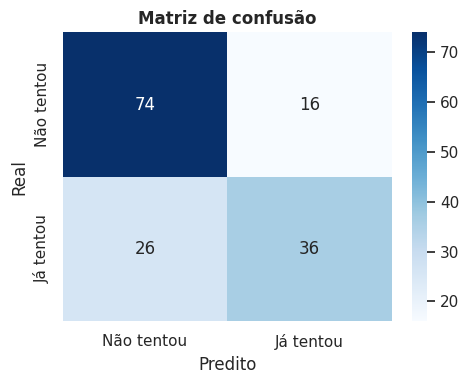

In [11]:
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Não tentou", "Já tentou"],
            yticklabels=["Não tentou", "Já tentou"])
plt.title("Matriz de confusão", fontweight="bold")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.savefig(DOCS_DIR / "04_matriz_confusao.png", dpi=150, bbox_inches="tight")
plt.show()

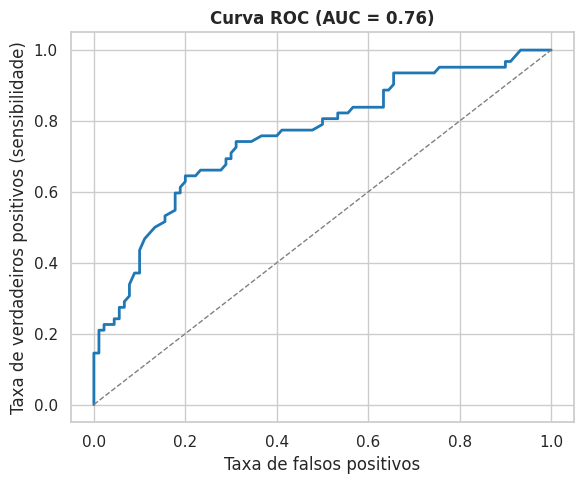

In [12]:
fpr, tpr, thresholds = roc_curve(y, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#1f77b4", lw=2)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
plt.title(f"Curva ROC (AUC = {roc_auc:.2f})", fontweight="bold")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos (sensibilidade)")
plt.tight_layout()
plt.show()

In [13]:
# Intervalo de confiança do AUC via bootstrap.
# Com amostras pequenas (n=152), reportar apenas o AUC pontual pode ser enganoso.
# O bootstrap reamostra os dados com reposição 2000 vezes e calcula o AUC em cada
# iteração, produzindo uma distribuição empírica da métrica. O percentil 2.5 e 97.5
# dessa distribuição formam o intervalo de confiança de 95%.

from sklearn.metrics import roc_auc_score

def bootstrap_auc(y_true, y_prob, n_bootstrap=2000, ci=0.95, random_state=2026):
    """Calcula o intervalo de confiança do AUC por bootstrap."""
    rng = np.random.default_rng(random_state)
    aucs = []
    for _ in range(n_bootstrap):
        idx = rng.choice(len(y_true), len(y_true), replace=True)
        # Pular amostras que contenham apenas uma classe (AUC indefinido).
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    aucs = np.array(aucs)
    alpha = (1 - ci) / 2
    lower = np.percentile(aucs, alpha * 100)
    upper = np.percentile(aucs, (1 - alpha) * 100)
    return lower, upper, aucs

lower, upper, aucs_boot = bootstrap_auc(y.values, y_proba)
print(f"AUC pontual: {roc_auc:.2f}")
print(f"AUC IC 95% (bootstrap, n=2000): [{lower:.2f}, {upper:.2f}]")
print(f"AUC médio bootstrap: {aucs_boot.mean():.2f} (desvio padrão: {aucs_boot.std():.2f})")

AUC pontual: 0.76
AUC IC 95% (bootstrap, n=2000): [0.68, 0.83]
AUC médio bootstrap: 0.76 (desvio padrão: 0.04)


## 6. Threshold ótimo (Youden's J)

In [14]:
J = tpr - fpr
idx_otimo = J.argmax()
threshold_otimo = thresholds[idx_otimo]

print(f"Threshold ótimo: {threshold_otimo:.3f}")
print(f"Sensibilidade:   {tpr[idx_otimo]:.3f}")
print(f"Especificidade:  {1 - fpr[idx_otimo]:.3f}")

Threshold ótimo: 0.470
Sensibilidade:   0.645
Especificidade:  0.800


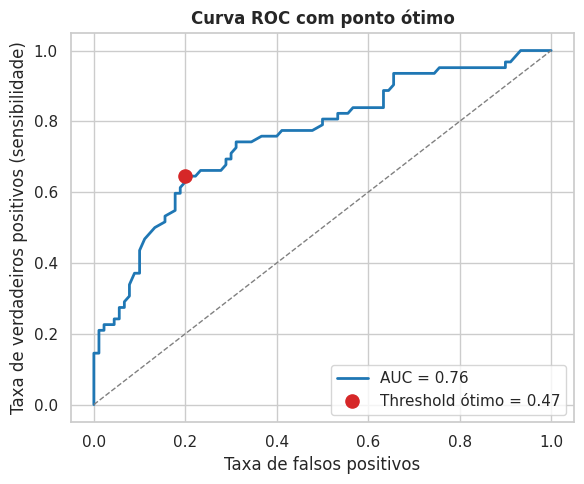

In [15]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#1f77b4", lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
plt.scatter(fpr[idx_otimo], tpr[idx_otimo], color="#d62728", s=90, zorder=5,
            label=f"Threshold ótimo = {threshold_otimo:.2f}")
plt.title("Curva ROC com ponto ótimo", fontweight="bold")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos (sensibilidade)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(DOCS_DIR / "04_roc_reutilizacao.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
y_pred_otimo = (y_proba >= threshold_otimo).astype(int)

print("Classification report com threshold ótimo:")
print(classification_report(y, y_pred_otimo, target_names=["Não tentou", "Já tentou"]))

Classification report com threshold ótimo:
              precision    recall  f1-score   support

  Não tentou       0.77      0.80      0.78        90
   Já tentou       0.69      0.65      0.67        62

    accuracy                           0.74       152
   macro avg       0.73      0.72      0.72       152
weighted avg       0.73      0.74      0.74       152



## 7. Feature importance

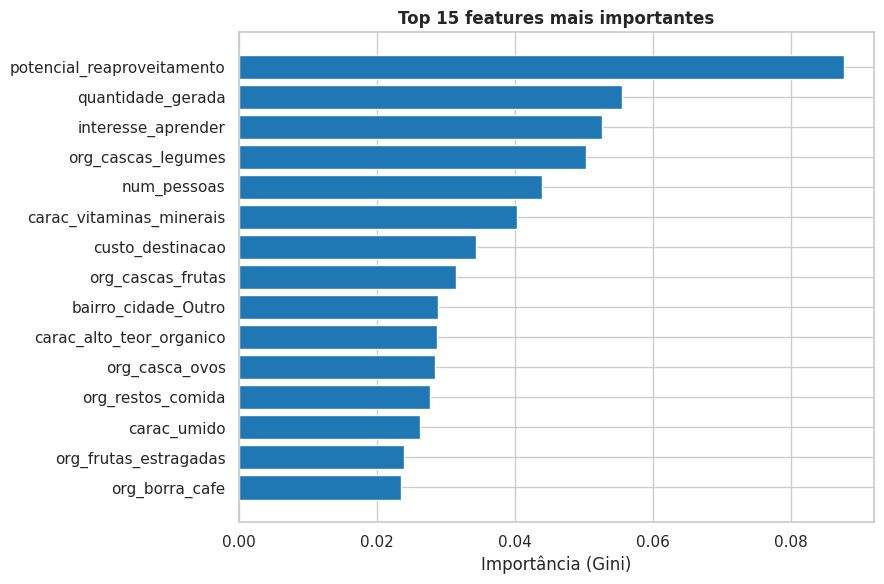

In [17]:
rf.fit(X, y)

importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
top15 = importancias.tail(15)

plt.figure(figsize=(9, 6))
plt.barh(top15.index, top15.values, color="#1f77b4")
plt.title("Top 15 features mais importantes", fontweight="bold")
plt.xlabel("Importância (Gini)")
plt.tight_layout()
plt.savefig(DOCS_DIR / "04_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Oportunidade oculta

Com o threshold ótimo, identificamos entre as pessoas que nunca tentaram reutilizar aquelas que têm perfil para fazê-lo. São pessoas que, pelo conjunto de respostas sobre percepção e contexto, deveriam estar reutilizando. Essa é a oportunidade concreta de intervenção.

In [18]:
mask_nao_tentou = (y == 0)
proba_nao_tentou = y_proba[mask_nao_tentou]
perfil_reutiliza = (proba_nao_tentou >= threshold_otimo).sum()
total_nao = mask_nao_tentou.sum()

print(f"Das {total_nao} pessoas que nunca tentaram reutilizar, "
      f"{perfil_reutiliza} têm perfil de reutilização ({perfil_reutiliza/total_nao:.0%})")

Das 90 pessoas que nunca tentaram reutilizar, 18 têm perfil de reutilização (20%)


## Comparação entre os dois modelos

- **Notebook 03 (target: `destino_atual`)**: AUC = 0.50. Perfil e percepção, sozinhos, não preveem o destino final do resíduo.
- **Notebook 04 (target: `tentativa_reutilizacao`)**: AUC = 0.76. Perfil e percepção conseguem prever melhor a tentativa de reutilização.

Interpretação: o destino dado ao resíduo depende fortemente de fatores externos, como infraestrutura e coleta disponível, que não estão no questionário. Já a tentativa de reutilização depende mais de fatores internos, como percepção de reaproveitamento, interesse e conhecimento. Isso indica que intervenções de conscientização podem impactar a reutilização mais diretamente do que o destino de descarte.

## 9. A história das top 5 features

As 5 features mais importantes formam uma cadeia coerente: crença, interesse e volume.

1. `potencial_reaproveitamento` - acredita que o resíduo pode ser reaproveitado
2. `org_cascas_legumes` - lida com orgânicos no dia a dia (cascas de legumes e verduras)
3. `interesse_aprender` - quer aprender formas de reaproveitamento
4. `quantidade_gerada` - gera volume relevante de resíduos
5. `num_pessoas` - mais pessoas no local, mais geração

O modelo está dizendo: a pessoa que reutiliza é a que já tem o ciclo mental completo. Percebe o valor, quer agir e tem matéria-prima. As 18 pessoas identificadas na oportunidade oculta têm tudo isso, menos a ação.

## 10. Contraste entre os dois modelos

O notebook 03 não falhou. Ele produziu um resultado. Prever destino a partir de percepção não funciona (AUC = 0.50) porque destino depende de fatores externos: infraestrutura de coleta, acesso a composteiras, proximidade de pontos de coleta seletiva. Prever reutilização funciona (AUC = 0.76) porque reutilização depende de fatores internos: percepção, interesse, conhecimento.

A implicação prática é direta: investir em conscientização pode mudar o comportamento de reutilização, mas não muda o destino de descarte enquanto a infraestrutura não chegar. Isso justifica o foco do projeto interdisciplinar. O trabalho da Engenharia Química (demonstrar o valor dos resíduos orgânicos) atua exatamente sobre os fatores que o modelo identificou como mais preditivos.

## 11. Quem são as 18 pessoas com perfil de reutilização que nunca tentaram?

O número "18 pessoas" ganha significado quando entendemos quem elas são. Abaixo, recarregamos os dados originais (antes do encoding) e mostramos o perfil agregado desse grupo, sem identificar ninguém individualmente.

In [19]:
# Recarregar dados originais (antes do encoding) para mostrar o perfil
# das 18 pessoas com oportunidade oculta em texto legível.
df_original = pd.read_csv("../dados/respostas_limpo.csv")
df_original = df_original.dropna(subset=["num_pessoas", "interesse_aprender"])

# Mesma mask usada na seção 8: nunca tentou + modelo diz que tem perfil
mask_oportunidade = mask_nao_tentou & (y_proba >= threshold_otimo)
df_oportun = df_original.loc[mask_oportunidade.values]

print(f"Perfil das {len(df_oportun)} pessoas com oportunidade oculta:\n")

print("Tipo de gerador:")
for v, c in df_oportun["tipo_gerador"].value_counts().items():
    print(f"  {v:<40} {c}")

print("\nBairros mais frequentes (top 5):")
for v, c in df_oportun["bairro_cidade"].value_counts().head(5).items():
    print(f"  {v:<40} {c}")

print("\nQuantidade gerada:")
for v, c in df_oportun["quantidade_gerada"].value_counts().items():
    print(f"  {v:<50} {c}")

print("\nPotencial de reaproveitamento:")
for v, c in df_oportun["potencial_reaproveitamento"].value_counts().items():
    print(f"  {v:<40} {c}")

print("\nResíduos orgânicos mais citados:")
organicos_chave = [
    ("Cascas de legumes e verduras", "Cascas de legumes e verduras"),
    ("Cascas de frutas", "Cascas de frutas"),
    ("Restos de comida", "Restos de comida"),
    ("Casca de ovos", "Casca de ovos"),
    ("Borra de café", "Borra de café"),
]
serie_org = df_oportun["residuos_organicos"].fillna("")
for label, substring in organicos_chave:
    n = serie_org.str.contains(substring, regex=False).sum()
    print(f"  {label:<40} {n}/{len(df_oportun)}")

Perfil das 18 pessoas com oportunidade oculta:

Tipo de gerador:
  Pessoa física (residência)               17
  Instituição pública                      1

Bairros mais frequentes (top 5):
  Primavera                                3
  Jardim Itália                            2
  Desbravador                              2
  Centro                                   2
  Xaxim                                    2

Quantidade gerada:
  1–5 kg por semana                                  9
  5–10 kg por semana                                 5
  10–50 kg por semana                                2
  Não sei estimar                                    2

Potencial de reaproveitamento:
  Sim                                      18

Resíduos orgânicos mais citados:
  Cascas de legumes e verduras             10/18
  Cascas de frutas                         12/18
  Restos de comida                         15/18
  Casca de ovos                            9/18
  Borra de café                       

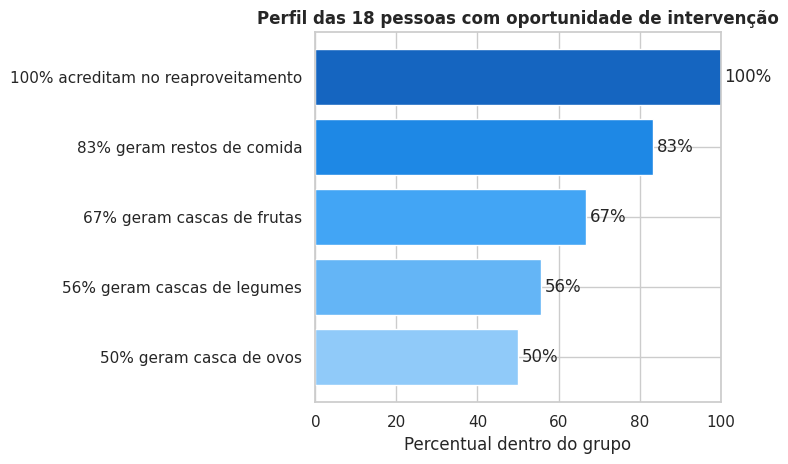

In [20]:
# Gráfico-resumo do perfil das 18 pessoas com oportunidade oculta
indicadores = pd.Series({
    "100% acreditam no reaproveitamento": (df_oportun["potencial_reaproveitamento"] == "Sim").mean() * 100,
    "83% geram restos de comida": df_oportun["residuos_organicos"].fillna("").str.contains("Restos de comida", regex=False).mean() * 100,
    "67% geram cascas de frutas": df_oportun["residuos_organicos"].fillna("").str.contains("Cascas de frutas", regex=False).mean() * 100,
    "56% geram cascas de legumes": df_oportun["residuos_organicos"].fillna("").str.contains("Cascas de legumes e verduras", regex=False).mean() * 100,
    "50% geram casca de ovos": df_oportun["residuos_organicos"].fillna("").str.contains("Casca de ovos", regex=False).mean() * 100,
}).sort_values()

plt.figure(figsize=(8, 4.8))
bars = plt.barh(indicadores.index, indicadores.values, color=["#90CAF9", "#64B5F6", "#42A5F5", "#1E88E5", "#1565C0"])
plt.xlim(0, 100)
plt.xlabel("Percentual dentro do grupo")
plt.title("Perfil das 18 pessoas com oportunidade de intervenção", fontweight="bold")
for bar, value in zip(bars, indicadores.values):
    plt.text(value + 1, bar.get_y() + bar.get_height() / 2, f"{value:.0f}%", va="center")
plt.tight_layout()
plt.savefig(DOCS_DIR / "04_perfil_oportunidade.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Quantificação da oportunidade em kg

As 18 pessoas identificadas como oportunidade de intervenção não são apenas um número. Cada uma gera uma quantidade semanal de resíduos orgânicos que poderia ser reaproveitada. Ao quantificar esse volume, transformamos o resultado do modelo em uma estimativa concreta de desperdício evitável.

As 18 pessoas com oportunidade de intervenção geram juntas:
  130 kg por semana
  522 kg por mês
  6786 kg por ano
de resíduos orgânicos que poderiam ser reaproveitados.


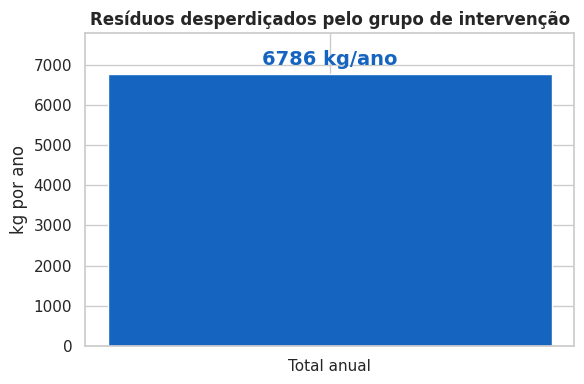

In [21]:
# Mapear quantidade_gerada para pontos médios em kg/semana.
# Os valores representam o centro de cada faixa do questionário.
mapa_kg = {
    "menos 1kg": 0.5,
    "Menos de 1kg por semana, nem toda semana gera resíduo": 0.5,
    "Um kilo mais ou menos": 1.0,
    "1–5 kg por semana": 3.0,
    "5–10 kg por semana": 7.5,
    "10–50 kg por semana": 30.0,
}

kg_semana = df_oportun["quantidade_gerada"].map(mapa_kg)

# "Não sei estimar" ficou como NaN; preenchido com a mediana das demais faixas.
mediana_kg = kg_semana.dropna().median()
kg_semana = kg_semana.fillna(mediana_kg)

total_semana = kg_semana.sum()
total_mes = total_semana * 4
total_ano = total_semana * 52

print("As 18 pessoas com oportunidade de intervenção geram juntas:")
print(f"  {total_semana:.0f} kg por semana")
print(f"  {total_mes:.0f} kg por mês")
print(f"  {total_ano:.0f} kg por ano")
print("de resíduos orgânicos que poderiam ser reaproveitados.")

# Gráfico com destaque visual no total anual
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Total anual"], [total_ano], color="#1565C0", width=0.4)
ax.set_ylabel("kg por ano")
ax.set_title("Resíduos desperdiçados pelo grupo de intervenção", fontweight="bold")
ax.text(0, total_ano + total_ano * 0.03, f"{total_ano:.0f} kg/ano",
        ha="center", fontsize=14, fontweight="bold", color="#1565C0")
ax.set_ylim(0, total_ano * 1.15)
plt.tight_layout()
plt.savefig(DOCS_DIR / "04_kg_oportunidade.png", dpi=150, bbox_inches="tight")
plt.show()

## Próximos passos

As features mais importantes e o threshold serão usados nas fichas preditivas por tipo de resíduo.

## Limitações

- A amostra é preliminar (n=152 após remoção de NaN) e a coleta ainda está em andamento.
- A exclusão de variáveis comportamentais preserva a interpretação do modelo, mas pode omitir interações reais entre ação passada e ação futura.
- O modelo foi treinado com dados preliminares. As importâncias e o threshold podem mudar quando a base final estiver completa.